In [1]:
# %load_ext IPython.extensions.autoreload
# %autoreload 0

# # -*- coding: utf-8 -*-

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd

import openpyxl

import sys
import os
import runpy

import requests
from io import StringIO
import json

import json
import glob
from pathlib import Path
import pickle

In [3]:
# os.chdir(r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo")

In [4]:
target_excels_fpath = r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\inputs\3. treatment\_target_excels"

# Operationalisation of variables

### TERYT reference tabels

In [5]:
# ref_tab = pd.read_excel(r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\inputs\shapefiles\polska\teryt_klucz_powiaty_gminy_lata_1999_2025-1.xlsx")

In [6]:
# sorted(ref_tab.nazwa_powiatu.astype(str).unique())

## Dane GUS

### Programme period: 2003-2007 (Bank Danych Lokalnych)

In [7]:
# ## TOTAL VALUE OF PROJECTS
# PL_projects_07_13 = pd.read_excel(r"data\inputs\3. treatment\dane_gov_pl\FE_2007_2013_bez_EFFR.xlsx", header = 0)
# PL_projects_07_13.shape
# PL_projects_07_13.head()

In [8]:
cols_to_keep = [ 'Kod' , 'Nazwa',
        'wartość całkowita projektów zakończonych;ogółem;dofinansowanie ze środków Unii Europejskiej (wydatki kwalifikowalne);31 grudnia;2011;[zł]',
        'wartość całkowita projektów zakończonych;ogółem;dofinansowanie ze środków Unii Europejskiej (wydatki kwalifikowalne);31 grudnia;2012;[zł]',
        'wartość całkowita projektów zakończonych;ogółem;dofinansowanie ze środków Unii Europejskiej (wydatki kwalifikowalne);31 grudnia;2013;[zł]',
        'wartość całkowita projektów zakończonych;ogółem;dofinansowanie ze środków Unii Europejskiej (wydatki kwalifikowalne);31 grudnia;2014;[zł]',
        'wartość całkowita projektów zakończonych;ogółem;dofinansowanie ze środków Unii Europejskiej (wydatki kwalifikowalne);31 grudnia;2015;[zł]',
        'wartość całkowita projektów zakończonych;ogółem;dofinansowanie ze środków Unii Europejskiej (wydatki kwalifikowalne);31 grudnia;2016;[zł]',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;wartość ogółem (wydatki kwalifikowalne + niekwalifikowalne);31 grudnia;2011;[zł]',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;wartość ogółem (wydatki kwalifikowalne + niekwalifikowalne);31 grudnia;2012;[zł]',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;wartość ogółem (wydatki kwalifikowalne + niekwalifikowalne);31 grudnia;2013;[zł]',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;wartość ogółem (wydatki kwalifikowalne + niekwalifikowalne);31 grudnia;2014;[zł]',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;wartość ogółem (wydatki kwalifikowalne + niekwalifikowalne);31 grudnia;2015;[zł]',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;wartość ogółem (wydatki kwalifikowalne + niekwalifikowalne);31 grudnia;2016;[zł]',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;wydatki kwalifikowalne ogółem;31 grudnia;2011;[zł]',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;wydatki kwalifikowalne ogółem;31 grudnia;2012;[zł]',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;wydatki kwalifikowalne ogółem;31 grudnia;2013;[zł]',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;wydatki kwalifikowalne ogółem;31 grudnia;2014;[zł]',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;wydatki kwalifikowalne ogółem;31 grudnia;2015;[zł]',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;wydatki kwalifikowalne ogółem;31 grudnia;2016;[zł]',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;dofinansowanie ze środków Unii Europejskiej (wydatki kwalifikowalne);31 grudnia;2011;[zł]',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;dofinansowanie ze środków Unii Europejskiej (wydatki kwalifikowalne);31 grudnia;2012;[zł]',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;dofinansowanie ze środków Unii Europejskiej (wydatki kwalifikowalne);31 grudnia;2013;[zł]',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;dofinansowanie ze środków Unii Europejskiej (wydatki kwalifikowalne);31 grudnia;2014;[zł]',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;dofinansowanie ze środków Unii Europejskiej (wydatki kwalifikowalne);31 grudnia;2015;[zł]',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;dofinansowanie ze środków Unii Europejskiej (wydatki kwalifikowalne);31 grudnia;2016;[zł]',
        'wartość całkowita projektów zakończonych;ogółem;wydatki kwalifikowalne ogółem;31 grudnia;2011;[zł]',
        'wartość całkowita projektów zakończonych;ogółem;wydatki kwalifikowalne ogółem;31 grudnia;2012;[zł]',
        'wartość całkowita projektów zakończonych;ogółem;wydatki kwalifikowalne ogółem;31 grudnia;2013;[zł]',
        'wartość całkowita projektów zakończonych;ogółem;wydatki kwalifikowalne ogółem;31 grudnia;2014;[zł]',
        'wartość całkowita projektów zakończonych;ogółem;wydatki kwalifikowalne ogółem;31 grudnia;2015;[zł]',
        'wartość całkowita projektów zakończonych;ogółem;wydatki kwalifikowalne ogółem;31 grudnia;2016;[zł]',
]

In [9]:
# PL_projects_07_13 = PL_projects_07_13[cols_to_keep]

In [10]:
cols_rename_dict = { 'Kod' : 'code' , 'Nazwa' : 'name',
        'wartość całkowita projektów zakończonych;ogółem;dofinansowanie ze środków Unii Europejskiej (wydatki kwalifikowalne);31 grudnia;2011;[zł]' : 'total_eligible_value_completed_projects_EU_funding_2011_PLN',
        'wartość całkowita projektów zakończonych;ogółem;dofinansowanie ze środków Unii Europejskiej (wydatki kwalifikowalne);31 grudnia;2012;[zł]' : 'total_eligible_value_completed_projects_EU_funding_2012_PLN',
        'wartość całkowita projektów zakończonych;ogółem;dofinansowanie ze środków Unii Europejskiej (wydatki kwalifikowalne);31 grudnia;2013;[zł]' : 'total_eligible_value_completed_projects_EU_funding_2013_PLN',
        'wartość całkowita projektów zakończonych;ogółem;dofinansowanie ze środków Unii Europejskiej (wydatki kwalifikowalne);31 grudnia;2014;[zł]' : 'total_eligible_value_completed_projects_EU_funding_2014_PLN',
        'wartość całkowita projektów zakończonych;ogółem;dofinansowanie ze środków Unii Europejskiej (wydatki kwalifikowalne);31 grudnia;2015;[zł]' : 'total_eligible_value_completed_projects_EU_funding_2015_PLN',
        'wartość całkowita projektów zakończonych;ogółem;dofinansowanie ze środków Unii Europejskiej (wydatki kwalifikowalne);31 grudnia;2016;[zł]' : 'total_eligible_value_completed_projects_EU_funding_2016_PLN',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;wartość ogółem (wydatki kwalifikowalne + niekwalifikowalne);31 grudnia;2011;[zł]' : 'total_value_signed_financing_agreements_total_value_2011_PLN',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;wartość ogółem (wydatki kwalifikowalne + niekwalifikowalne);31 grudnia;2012;[zł]' : 'total_value_signed_financing_agreements_total_value_2012_PLN',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;wartość ogółem (wydatki kwalifikowalne + niekwalifikowalne);31 grudnia;2013;[zł]' : 'total_value_signed_financing_agreements_total_value_2013_PLN',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;wartość ogółem (wydatki kwalifikowalne + niekwalifikowalne);31 grudnia;2014;[zł]' : 'total_value_signed_financing_agreements_total_value_2014_PLN',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;wartość ogółem (wydatki kwalifikowalne + niekwalifikowalne);31 grudnia;2015;[zł]' : 'total_value_signed_financing_agreements_total_value_2015_PLN',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;wartość ogółem (wydatki kwalifikowalne + niekwalifikowalne);31 grudnia;2016;[zł]' : 'total_value_signed_financing_agreements_total_value_2016_PLN',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;wydatki kwalifikowalne ogółem;31 grudnia;2011;[zł]' : 'total_eligible_value_signed_financing_agreements_2011_PLN',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;wydatki kwalifikowalne ogółem;31 grudnia;2012;[zł]' : 'total_eligible_value_signed_financing_agreements_2012_PLN',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;wydatki kwalifikowalne ogółem;31 grudnia;2013;[zł]': 'total_eligible_value_signed_financing_agreements_2013_PLN',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;wydatki kwalifikowalne ogółem;31 grudnia;2014;[zł]' : 'total_eligible_value_signed_financing_agreements_2014_PLN',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;wydatki kwalifikowalne ogółem;31 grudnia;2015;[zł]': 'total_eligible_value_signed_financing_agreements_2015_PLN',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;wydatki kwalifikowalne ogółem;31 grudnia;2016;[zł]' : 'total_eligible_value_signed_financing_agreements_2016_PLN',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;dofinansowanie ze środków Unii Europejskiej (wydatki kwalifikowalne);31 grudnia;2011;[zł]' : 'total_eligible_value_signed_financing_agreements_EU_funding_2011_PLN',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;dofinansowanie ze środków Unii Europejskiej (wydatki kwalifikowalne);31 grudnia;2012;[zł]' : 'total_eligible_value_signed_financing_agreements_EU_funding_2012_PLN',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;dofinansowanie ze środków Unii Europejskiej (wydatki kwalifikowalne);31 grudnia;2013;[zł]' : 'total_eligible_value_signed_financing_agreements_EU_funding_2013_PLN',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;dofinansowanie ze środków Unii Europejskiej (wydatki kwalifikowalne);31 grudnia;2014;[zł]': 'total_eligible_value_signed_financing_agreements_EU_funding_2014_PLN',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;dofinansowanie ze środków Unii Europejskiej (wydatki kwalifikowalne);31 grudnia;2015;[zł]': 'total_eligible_value_signed_financing_agreements_EU_funding_2015_PLN',
        'wartość całkowita podpisanych umów o dofinansowanie;ogółem;dofinansowanie ze środków Unii Europejskiej (wydatki kwalifikowalne);31 grudnia;2016;[zł]' : 'total_eligible_value_signed_financing_agreements_EU_funding_2016_PLN',
        'wartość całkowita projektów zakończonych;ogółem;wydatki kwalifikowalne ogółem;31 grudnia;2011;[zł]' : 'total_eligible_value_completed_projects_2011_PLN',
        'wartość całkowita projektów zakończonych;ogółem;wydatki kwalifikowalne ogółem;31 grudnia;2012;[zł]' : 'total_eligible_value_completed_projects_2012_PLN',
        'wartość całkowita projektów zakończonych;ogółem;wydatki kwalifikowalne ogółem;31 grudnia;2013;[zł]' : 'total_eligible_value_completed_projects_2013_PLN',
        'wartość całkowita projektów zakończonych;ogółem;wydatki kwalifikowalne ogółem;31 grudnia;2014;[zł]' : 'total_eligible_value_completed_projects_2014_PLN',
        'wartość całkowita projektów zakończonych;ogółem;wydatki kwalifikowalne ogółem;31 grudnia;2015;[zł]': 'total_eligible_value_completed_projects_2015_PLN',
        'wartość całkowita projektów zakończonych;ogółem;wydatki kwalifikowalne ogółem;31 grudnia;2016;[zł]' : 'total_eligible_value_completed_projects_2016_PLN',
}

In [11]:
# PL_projects_07_13.rename(columns=cols_rename_dict, inplace=True)

In [12]:
# PL_projects_07_13.head(3)

In [13]:
# 1. IDENTIFY ID COLUMNS
# df = PL_projects_07_13.copy()
# id_cols = ['code', 'name'] 

# # 2. MELT THE DATAFRAME -->  converts columns to rows
# df_melted = df.melt(id_vars=id_cols, var_name='raw_column', value_name='Value_PLN')

# # 3. EXTRACT VARIABLE AND YEAR
# # We use regex to capture: (Everything before the year) _ (The Year) _ PLN
# pattern = r'^(.*)_(\d{4})_PLN$'

# extracted_data = df_melted['raw_column'].str.extract(pattern)
# df_melted['variable'] = extracted_data[0] # The long variable name
# df_melted['Year'] = extracted_data[1]   # The Year (2011, 2012...)

# # 4. PIVOT TO DESIRED STRUCTURE
# df_final = df_melted.pivot_table(
#     index=id_cols + ['variable'], 
#     columns='Year', 
#     values='Value_PLN',
#     aggfunc='sum' # Use sum just in case there are duplicates, usually not needed
# ).reset_index()

# # Optional: Clean up the column names (remove the 'Year' label)
# df_final.columns.name = None

In [14]:
# df_final['EUR_PL_rate'] = 4.4975

In [15]:
# # 1. Define the columns that contain the values to convert
# year_cols = ['2011', '2012', '2013', '2014', '2015', '2016']
# exchange_rate = 4.4975

# # 2. Create a copy of the dataframe so we don't overwrite the PLN data
# df_eur = df_final.copy()

# # 3. Perform the conversion (Division)
# df_eur[year_cols] = df_eur[year_cols] / exchange_rate

# # 4. Update the 'variable' column name to reflect the change
# df_eur['variable'] = df_eur['variable'] + '_EUR'

# df_combined = pd.concat([df_final, df_eur], ignore_index=True)
# df_combined = df_combined.sort_values(by=['code', 'variable'])


In [16]:
# df_combined.to_parquet(r'data/clean/treatment/eu_flows/gmina_FE_2007_13_pln_eur.parquet')

## Umowy 2007-2013


#### Basic cleaning

In [17]:
umowy_200713_POKL= pd.read_excel(r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\inputs\3. treatment\dane_gov_pl\umowy\Umowy_wszystko_POKL_30_06_2018.xls",
                    sheet_name = [0,1],
                    header = 1)

In [18]:
umowy_200713_INNE = pd.read_excel(r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\inputs\3. treatment\dane_gov_pl\umowy\Umowy_wszystko_INNE_30_06_2018.xls",
                    sheet_name = [0,1],
                    header = 1)

In [19]:
umowy_200713_INNE_all = pd.concat(umowy_200713_INNE.values(), ignore_index=True)
umowy_200713_POKL_all = pd.concat(umowy_200713_POKL.values(), ignore_index=True)

In [20]:
umowy_200713_INNE_all.rename(columns={
                                "Data rozpoczęcia realizacji " : "Data rozpoczęcia realizacji",
                                "Województwo" : "Województwo.1",
                                "Cały kraj/ Województwo" : "Województwo"
                                },
                                inplace = True
)

In [21]:
umowy_200713_POKL_all.columns == umowy_200713_INNE_all.columns 

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True])

In [22]:
umowy_200713 = pd.concat([umowy_200713_POKL_all, umowy_200713_INNE_all], ignore_index=True)

In [23]:
umowy_200713.columns

Index(['Numer umowy/aneksu/decyzji', 'Tytuł projektu',
       'Program Operacyjny <Nazwa>', 'Oś priorytetowa <Kod>',
       'Działanie <Kod>', 'Poddziałanie <Kod>', 'Województwo', 'Powiat',
       'Gmina', 'Wartość ogółem', 'Wydatki kwalifikowalne', 'Dofinansowanie',
       'Dofinansowanie UE', 'Nazwa beneficjenta', 'NIP beneficjenta',
       'Kod pocztowy', 'Miejscowość', 'Województwo.1', 'Powiat.1',
       'Temat priorytetu', 'Forma prawna', 'Obszar realizacji',
       'Projekt zakończony (Wniosek o płatność końcową)',
       'Data podpisania Umowy/Aneksu',
       'Data utworzenia w KSI SIMIK 07-13 Umowy/Aneksu',
       'Data rozpoczęcia realizacji', 'Data zakończenia realizacji'],
      dtype='object')

METADATA - COLUMNY ORYGINALNE

        'Numer umowy/aneksu/decyzji', 'Tytuł projektu',
        'Program Operacyjny <Nazwa>', 'Oś priorytetowa <Kod>',
        'Działanie <Kod>', 'Poddziałanie <Kod>', 'Województwo', 'Powiat',
        'Gmina', 'Wartość ogółem', 'Wydatki kwalifikowalne', 'Dofinansowanie',
        'Dofinansowanie UE', 'Nazwa beneficjenta', 'NIP beneficjenta',
        'Kod pocztowy', 'Miejscowość', 'Województwo.1', 'Powiat.1',
        'Temat priorytetu', 'Forma prawna', 'Obszar realizacji',
        'Projekt zakończony (Wniosek o płatność końcową)',
        'Data podpisania Umowy/Aneksu',
        'Data utworzenia w KSI SIMIK 07-13 Umowy/Aneksu',
        'Data rozpoczęcia realizacji', 'Data zakończenia realizacji'

In [24]:
rename_dict = {
                "Numer umowy/aneksu/decyzji" : "ID",
                "Tytuł projektu" : "project_title",
                "Program Operacyjny <Nazwa>" : 'program',
                "Oś priorytetowa <Kod>" : 'priority_code',
                "Działanie <Kod>" : "action_code",
                "Poddziałanie <Kod>" : "subaction_code",
                "Województwo" : "voviodeship",
                "Powiat" : "powiat",
                "Gmina" : "gmina",
                "Wartość ogółem" : "total_value_PLN",
                "Wydatki kwalifikowalne" : "eligible_expenses_PLN",
                "Dofinansowanie" : "subsidy_PLN",
                "Dofinansowanie UE" : "EU_subsidy_PLN",
                "Nazwa beneficjenta" : "beneficiary",
                "NIP beneficjenta" : "beneficiary_ID",
                "Kod pocztowy" : "beneficiary_postal_code",
                "Miejscowość" : "beneficiary_city",
                "Województwo.1" : "beneficiary_voviodeship",
                "Powiat.1" : "beneficiary_powiat",
                "Temat priorytetu" : "priority_theme",
                "Forma prawna" : "beneficiary_status",
                "Obszar realizacji" : "terriority_type",
                "Projekt zakończony (Wniosek o płatność końcową)" : "project_completed",
                "Data podpisania Umowy/Aneksu" : "signing_date",
                "Data utworzenia w KSI SIMIK 07-13 Umowy/Aneksu" : "creation_date_KSI_SIMIK_07_12",
                "Data rozpoczęcia realizacji" : "start_date",
                "Data zakończenia realizacji" : "end_date"
}


In [25]:
umowy_200713.rename(columns=rename_dict, inplace=True)

In [26]:
# umowy_200713.to_parquet(r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\clean\treatment\eu_flows\intermediary\umowy_200713_clean.parquet", index = False)

In [27]:
#detect related projects
# from rapidfuzz import fuzz

# threshold = 90  # Similarity threshold (0-100)
# related_pairs = []

# ids = umowy_200713['ID'].dropna().unique()

# for i, id1 in enumerate(ids):
#     for id2 in ids[i+1:]:
#         score = fuzz.token_set_ratio(id1, id2)
#         if score > threshold:
#             related_pairs.append((id1, id2, score))

MEATDATA 

For metadata/ data cleaning pipeline

1. projects that covered the entire territory of the country were removed from the analysis 
    - for 2007-2013 projects this is  31 520 023 323.54 zł = 31.5 mln PLN
    - 4917 projektów/ umów
2. For projects where the implementation place (gmina/powiat) was not explicitly coded at the municipal level, the beneficiary's registered address (Miejscowość) was used as a geographic proxy.

   --> To prevent Headquarters Bias (over-attribution to administrative capitals), a keyword exclusion filter was applied. Projects managed by National Ministries, State Authorities, or Central Agencies remained in the "Systemic" category, while funding for local NGOs, schools, and private enterprises was successfully re-attributed to their respective Gminas.

In [28]:

print(sum(umowy_200713["voviodeship"] == 'Cały kraj'))
print(umowy_200713["powiat"].isna().sum())
print(umowy_200713["gmina"].isna().sum())


4917
18248
39185


In [29]:
display(umowy_200713.describe(), umowy_200713.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150551 entries, 0 to 150550
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   ID                             150551 non-null  object        
 1   project_title                  150551 non-null  object        
 2   program                        150551 non-null  object        
 3   priority_code                  150551 non-null  object        
 4   action_code                    150551 non-null  object        
 5   subaction_code                 71460 non-null   object        
 6   voviodeship                    150551 non-null  object        
 7   powiat                         132303 non-null  object        
 8   gmina                          111366 non-null  object        
 9   total_value_PLN                150551 non-null  float64       
 10  eligible_expenses_PLN          150551 non-null  float64       
 11  

,total_value_PLN,eligible_expenses_PLN,subsidy_PLN,EU_subsidy_PLN,signing_date,creation_date_KSI_SIMIK_07_12,start_date,end_date
count,1.505510e+05,1.505510e+05,1.505510e+05,1.505510e+05,150551,150551,150551,150551
mean,3.335112e+06,2.681124e+06,2.120429e+06,1.921407e+06,2012-11-15 08:30:48.697119488,2012-12-03 00:32:27.215229184,2011-03-01 22:30:18.041726720,2013-01-28 22:25:59.216478208
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2007-02-26 00:00:00,2008-01-08 00:00:00,2007-01-01 00:00:00,2007-09-30 00:00:00
25%,9.000000e+04,8.561504e+04,7.200000e+04,6.194123e+04,2010-12-14 00:00:00,2011-01-11 00:00:00,2009-08-17 00:00:00,2011-05-31 00:00:00
50%,3.708853e+05,3.487106e+05,2.698042e+05,2.374947e+05,2012-11-12 00:00:00,2012-11-23 00:00:00,2011-01-01 00:00:00,2012-12-31 00:00:00
75%,1.100571e+06,9.999891e+05,7.788332e+05,6.843347e+05,2014-07-25 00:00:00,2014-08-05 00:00:00,2012-10-01 00:00:00,2014-12-31 00:00:00
max,5.976094e+09,4.501605e+09,3.601284e+09,3.601284e+09,2018-06-28 00:00:00,2018-06-29 00:00:00,2015-12-30 00:00:00,2018-12-31 00:00:00
std,3.410411e+07,2.430345e+07,2.147717e+07,1.941051e+07,NaN,NaN,NaN,NaN


None

In [30]:
# sorted(umowy_200713.columns)

### MAON LOGIC OPERATION AND PROCESSING

In [31]:
# umowy_200713_filtered = umowy_200713[umowy_200713["voviodeship"] == 'Cały kraj']

In [59]:
os.chdir(r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\code\processing\UE_funds_processing")

from GUS_processing_functions import infer_geography, distribute_funding_over_time, read_and_parse, assign_geo_ids,build_teryt_lookup_optimized,parse_and_explode_locations


#build_teryt_lookups, assign_geo_ids, date_columns, 

In [33]:
# umowy_200713_infered=pd.read_csv(r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\clean\treatment\eu_flows\intermediary\umowy_200713_infered.csv",
#                                  low_memory=False
#                                  )

In [63]:
# df_200713_parsed = parse_and_explode_locations(umowy_200713)

In [ ]:
df_distributed = distribute_funding_over_time(df_200713_parsed)

In [40]:
import pandas as pd
import numpy as np
import re
import pickle
import os

# 1. Definiujemy funkcję pomocniczą GLOBALNIE (na zewnątrz)
def norm_text_global(s):
    if pd.isna(s): return ""
    s = str(s).lower()
    s = re.sub(r'\s+od\s+\d{4}', '', s)
    for pat in ['m.st.', 'm.', 'st.', 'miasto', 'powiat', '-', '.', ' ']:
        s = s.replace(pat, '')
    return s

# 2. Definiujemy funkcję budującą (korzysta z tej powyżej)
def build_teryt_lookup_fixed(path_excel):
    print(f"Loading TERYT data from: {path_excel}...")
    
    cols = ['region', 'nazwa_powiatu', 'nazwa_gminy', 'teryt_2025']
    try:
        df_g = pd.read_excel(path_excel, sheet_name='gminy', dtype=str, usecols=cols)
    except:
        df_g = pd.read_excel(path_excel, sheet_name='gminy', dtype=str)

    # Używamy funkcji globalnej
    woj_id = df_g['region'].astype(str).str.split('.').str[0].str.zfill(2)
    pow_norm = df_g['nazwa_powiatu'].apply(norm_text_global)
    gmi_norm = df_g['nazwa_gminy'].apply(norm_text_global)
    target_id = df_g['teryt_2025'].astype(str).str.split('.').str[0].str.zfill(7)

    # Mapy
    primary = dict(zip(zip(woj_id, pow_norm, gmi_norm), target_id))
    
    # Fallback
    df_g['key'] = list(zip(woj_id, gmi_norm))
    unique = df_g.groupby('key')['teryt_2025'].nunique()
    valid = unique[unique==1].index
    fallback_df = df_g.set_index('key').loc[valid]
    fallback = dict(zip(fallback_df.index, fallback_df['teryt_2025']))
    
    # Powiaty
    df_g['pid'] = target_id.str[:4]
    pdf = df_g[['region', 'nazwa_powiatu', 'pid']].drop_duplicates()
    pdf['pnorm'] = pdf['nazwa_powiatu'].apply(norm_text_global)
    powiaty = dict(zip(zip(pdf['region'].str.zfill(2), pdf['pnorm']), pdf['pid']))

    print("TERYT Lookup built successfully.")
    
    # ZWRACAMY funkcję globalną (pickle to zaakceptuje)
    return primary, fallback, powiaty, norm_text_global

In [41]:
# Upewnij się, że ścieżki są poprawne
PATH_TERYT = r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\inputs\shapefiles\polska\teryt_klucz_powiaty_gminy_lata_1999_2025-1.xlsx"
PATH_PKL = r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\outputs\teryt_lookup\teryt_lookup_2025.pkl"

# Generuj
lookup_tuple = build_teryt_lookup_fixed(PATH_TERYT)

# Zapisz
os.makedirs(os.path.dirname(PATH_PKL), exist_ok=True)
with open(PATH_PKL, "wb") as f:
    pickle.dump(lookup_tuple, f)

print("Sukces! Błąd pickle rozwiązany.")

Loading TERYT data from: C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\inputs\shapefiles\polska\teryt_klucz_powiaty_gminy_lata_1999_2025-1.xlsx...
TERYT Lookup built successfully.
Sukces! Błąd pickle rozwiązany.


In [42]:
df_distributed_assigned = assign_geo_ids(df_distributed, lookup_tuple)

In [44]:
# ==========================================
# STEP X: FILTER & REPORT (Run after assign_geo_ids)
# ==========================================
clean_fpath = r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\clean\treatment\eu_flows"

df_assigned =df_distributed_assigned.copy()
# 1. Define what is "Valid Powiat Data"
# Valid = Has a Powiat ID (This includes specific Gminas AND specific Powiats)
mask_valid_powiat = df_assigned['powiat_id'].notna()

# 2. Split the dataset
df_powiat_clean = df_assigned[mask_valid_powiat].copy()
df_regional_country = df_assigned[~mask_valid_powiat].copy()

# 3. REPORTING (For your Paper's Appendix)
print("--- DATA EXCLUSION REPORT ---")
print(f"Total rows processed: {len(df_assigned)}")
print(f"Rows with valid Powiat location: {len(df_powiat_clean)} ({len(df_powiat_clean)/len(df_assigned):.1%})")
print(f"Rows excluded (Voivodeship/Country level): {len(df_regional_country)} ({len(df_regional_country)/len(df_assigned):.1%})")

# Calculate Value Lost (Optional, if you have these columns)
if 'total_value_PLN' in df_assigned.columns:
    total_val = df_assigned['total_value_PLN'].sum()
    excluded_val = df_regional_country['total_value_PLN'].sum()
    print(f"Total Value (PLN): {total_val:,.0f}")
    print(f"Excluded Value (PLN): {excluded_val:,.0f} ({excluded_val/total_val:.1%})")

# 4. AGGREGATE TO POWIAT PANEL (The dataset you asked for)
# Now we sum up the clean data to the Powiat-Year level
group_cols = ['voivodeship_id', 'powiat_id', 'Year']
fin_cols = ['EU_subsidy_PLN', 'total_value_PLN', 'subsidy_PLN', 'eligible_expenses_PLN']
existing_fin = [c for c in fin_cols if c in df_powiat_clean.columns]

# Aggregation logic
agg_dict = {col: 'sum' for col in existing_fin}
# Keep names for readability (first one found)
for name_col in ['voviodeship', 'powiat']:
    if name_col in df_powiat_clean.columns:
        agg_dict[name_col] = 'first'

df_final_powiat_panel = df_powiat_clean.groupby(group_cols, as_index=False).agg(agg_dict)
df_final_powiat_panel = df_final_powiat_panel.sort_values(['powiat_id', 'Year'])

# 5. SAVE OUTPUTS
print("\nSaving files...")


df_final_powiat_panel.to_csv(
    f"{clean_fpath}/final/powiat_level_data_200713.csv",
    index=False
)
df_regional_country.to_csv(
    f"{clean_fpath}/intermediary/200713_appendix_excluded_regional_rows.csv",
    index=False
)

print("Done. Saved 'final_powiat_level_data.csv' and 'appendix_excluded_regional_rows.csv'.")

--- DATA EXCLUSION REPORT ---
Total rows processed: 406771
Rows with valid Powiat location: 360248 (88.6%)
Rows excluded (Voivodeship/Country level): 46523 (11.4%)
Total Value (PLN): 502,104,441,360
Excluded Value (PLN): 66,728,690,332 (13.3%)

Saving files...
Done. Saved 'final_powiat_level_data.csv' and 'appendix_excluded_regional_rows.csv'.


In [ ]:
# Using default file path
umowy_200713_infered = read_and_parse("umowy_200713_infered")
display(umowy_200713_infered.head(2), umowy_200713_infered.info())

In [45]:
powiaty_geoms = gpd.read_file(r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\inputs\shapefiles\polska\powiaty\powiaty.shp")
gminy_geoms = gpd.read_file(r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\inputs\shapefiles\polska\gminy\gminy.shp")

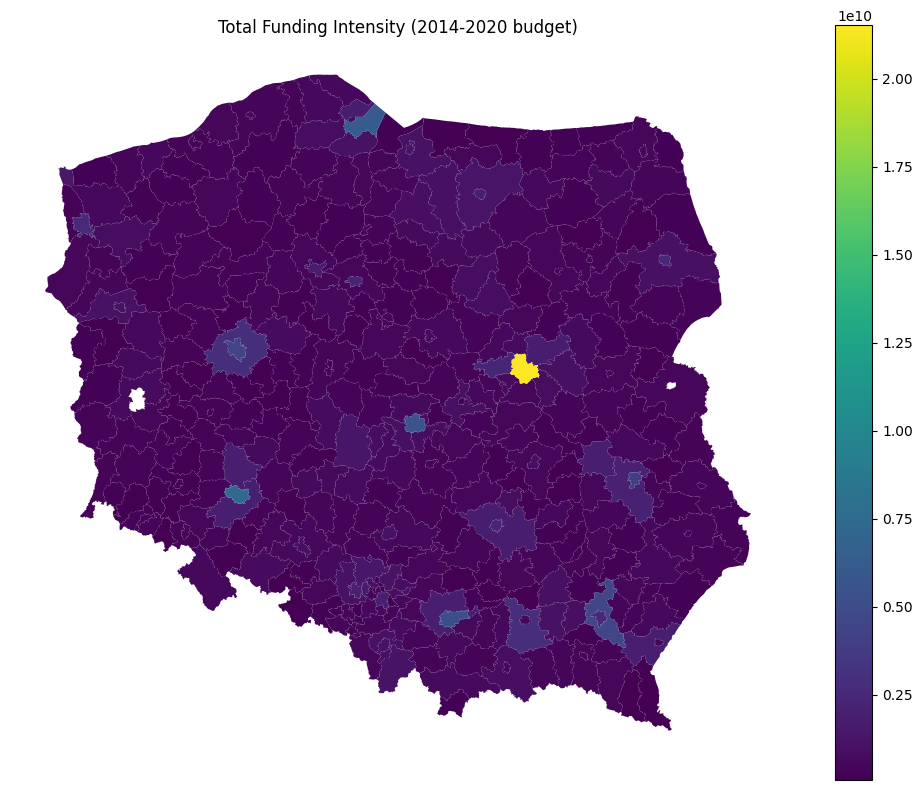

In [ ]:
import matplotlib.pyplot as plt

# Aggregate total funding per gmina (sum over all years)
agg_total = df_final_powiat_panel.groupby('powiat_id')['EU_subsidy_PLN'].sum().reset_index()


# 2. Merge with geometries
agg_total['powiat_id'] = agg_total['powiat_id'].astype(str).str.zfill(7)
powiaty_geoms['JPT_KOD_JE'] = powiaty_geoms['JPT_KOD_JE'].astype(str).str.zfill(7)
merged = agg_total.merge(powiaty_geoms, left_on='powiat_id', right_on='JPT_KOD_JE')
gdf = gpd.GeoDataFrame(merged, geometry='geometry')

# 3. Plot the total funding intensity map
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
gdf.plot(
    column='EU_subsidy_PLN',
    ax=ax,
    cmap='viridis',
    legend=True,
    missing_kwds={"color": "lightgrey"}
)
ax.set_title('Total Funding Intensity (2007-2013 budget)')
ax.axis('off')
plt.tight_layout()
plt.show()

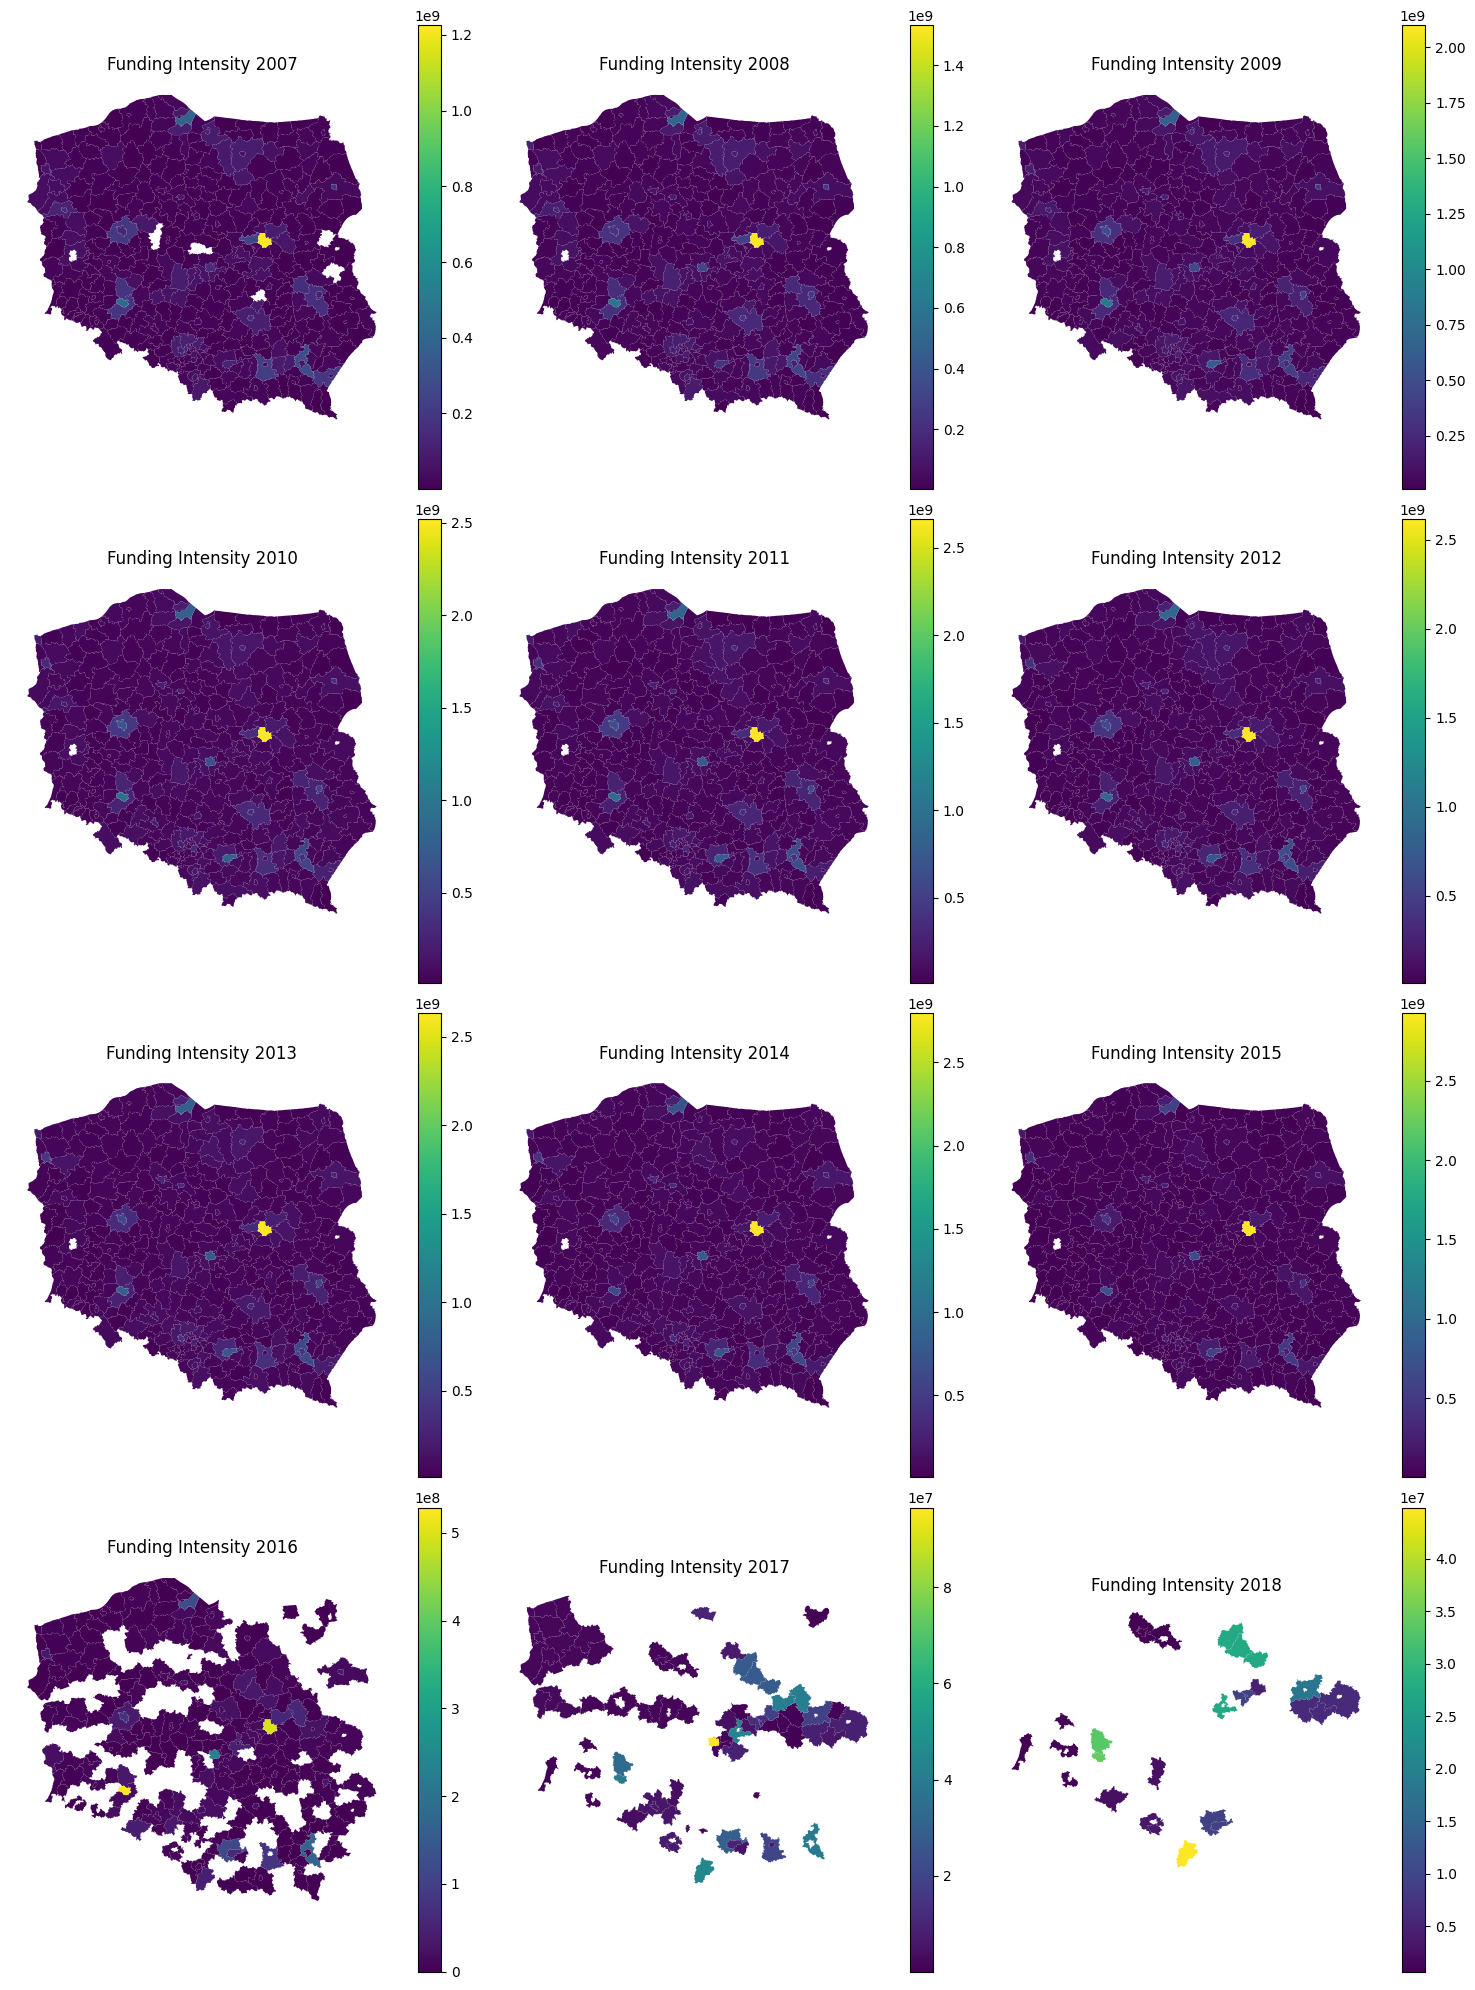

In [56]:
import matplotlib.pyplot as plt

# 1. Aggregate total funding per gmina (sum over all years)
agg = df_final_powiat_panel.groupby(['powiat_id','Year'])['EU_subsidy_PLN'].sum().reset_index()

# 2. Merge with geometries
agg['powiat_id'] = agg['powiat_id'].astype(str).str.zfill(7)
powiaty_geoms['JPT_KOD_JE'] = powiaty_geoms['JPT_KOD_JE'].astype(str).str.zfill(7)
merged = agg.merge(powiaty_geoms, left_on='powiat_id', right_on='JPT_KOD_JE')
gdf = gpd.GeoDataFrame(merged, geometry='geometry')

# 3. Plot for selected years (adjust years as needed)
years = sorted(gdf['Year'].unique())
n_years = len(years)
ncols = 3
nrows = (n_years + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    gdf[gdf['Year'] == year].plot(
        column='EU_subsidy_PLN',
        ax=ax,
        cmap='viridis',
        legend=True,
        missing_kwds={"color": "lightgrey"}
    )
    ax.set_title(f'Funding Intensity {year}')
    ax.axis('off')

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# # remove programmes that but store the treated units in a separate refrence table

# total_value_removed_PLN = umowy_200713.loc[umowy_200713["voviodeship"] == 'Cały kraj', "total_value_PLN"].sum()
# # umowy_200713.drop(umowy_200713[umowy_200713["voviodeship"] == 'Cały kraj'].index)

# print(f"{total_value_removed_PLN}")

In [ ]:
# # remove programmes that but store the treated units in a separate refrence table

# total_value_removed_PLN = umowy_200713_infered.loc[umowy_200713_infered["voviodeship"] == 'Cały kraj', "total_value_PLN"].sum()
# # umowy_200713.drop(umowy_200713[umowy_200713["voviodeship"] == 'Cały kraj'].index)

# print(f"{total_value_removed_PLN}")

In [ ]:
# print("Geographic information missing (2007-2013):")
# print(f"gmina:{umowy_200713_infered['gmina'].isna().sum()/umowy_200713_infered.shape[0]:.2%}")
# print(f"powiat {umowy_200713_infered['powiat'].isna().sum()/umowy_200713_infered.shape[0]:.2%}")
# print(f"województwo {umowy_200713_infered['voviodeship'].isna().sum()/umowy_200713_infered.shape[0]:.2%}")


In [ ]:
# umowy_200713_infered.to_csv(r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\clean\treatment\eu_flows\intermediary\umowy_200713_infered.csv",index=False)

In [ ]:
umowy_200713_infered.dtypes

In [ ]:
# umowy_200713_infered_distributed = read_and_parse(file_name="umowy_200713_infered_distributed")

umowy_200713_infered_distributed = distribute_funding_over_time(umowy_200713_infered)

display(umowy_200713_infered_distributed.info(), umowy_200713_infered_distributed.head(2))
(print(umowy_200713_infered.shape, umowy_200713_infered_distributed.shape))


In [ ]:
# umowy_200713_infered_distributed

In [ ]:
umowy_200713_infered_distributed.to_csv(r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\clean\treatment\eu_flows\intermediary\umowy_200713_infered_distributed.csv", index=False)

In [ ]:
powiaty_geoms = gpd.read_file(r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\inputs\shapefiles\polska\powiaty\powiaty.shp")

In [ ]:
# umowy_200713_infered.info(); umowy_200713_infered_distributed.info()


In [ ]:
# print(sum(umowy_200713["voviodeship"] == 'Cały kraj'))
print(umowy_200713_infered["powiat"].isna().sum())
print(umowy_200713_infered["gmina"].isna().sum())

In [ ]:
filtered = umowy_200713_infered.loc[
    (umowy_200713_infered["voviodeship"] == "Cały kraj") &
    (umowy_200713_infered["gmina"].notnull())]

In [ ]:
umowy_200713.ID.unique()

### Programme period: 2014 - 2020

In [ ]:
# projects_14_20 = pd.read_excel(r"data\inputs\dane_gus\lista_projektow_UE_2014_20\Lista_projektow_FE_2014_2020_02112025.xlsx", header = 2, decimal=',')

In [ ]:
# df = projects_14_20.copy()

#### Clean up data

In [ ]:
from src.functions import *

In [ ]:
df.drop(columns=[
    "Tytuł projektu/ Project name",
    "Skrócony opis [do 2000 znaków] / Project summary",
    "Forma finansowania/ Form of finance",
    "Projekt realizowany w ramach terytorialnych mechanizmów wdrażania/ Project implemented under territorial delivery mechanisms",
    "Działanie/ Measure",
    "Poddziałanie/ Submeasure",
    "Dziedzina działalności gospodarczej, której dotyczy projekt/ Area of economic activity",
    "Obszar wsparcia projektu/ Area of project intervention",
    "Cel projektu/ Project thematic objective",
    "Cel uzupełniający dla projektów EFS/ ESF secondary theme"
], inplace=True)
df = clean_english_colnames(df, normalize='keep')   
df = df[df['Fund'] != 'BAR'] 

In [ ]:
df.shape

### Programme period 2021-2027

In [ ]:
projects_21_27 = pd.read_excel(r"data\inputs\dane_gus\lista_projektow_UE_2021_27\Lista_projektow_FE_2021_2027_02112025.xlsx", header = 1, decimal=',')
df_new = projects_21_27.copy()
#### Clean up 
df_new.drop(columns=[
    "Działanie/ Measure",
    # "Cel szczegółowy/ Specific objective",
    "Priorytet/ Priority", 
    "Działanie/ Measure",
    "Numer identyfikacyjny statku w rejestrze floty rybackiej UE/ The Union fishing fleet register identification number",
    "Nazwa wykonawcy kontraktu/ The contractor’s name",
    "Kategoria wsparcia/ Type of intervention"
], inplace=True)

df_new = clean_english_colnames(df_new, normalize='keep')   
df_new = df_new[df_new['Fund'] != 'BAR'] 

df_new.drop(columns = ['Project name', 'Project summary', 'Specific objective',  'EURO exchange rate'], inplace=True)
# 4.4975 # this exchange rate was taken from the report
df_new.columns

### Concat 2014-20 and 2021-2027

#### unify colnames across all datasets

In [ ]:
df_new.rename(columns={
    
    'Total project value (PLN)': 'Total project value (PLN, for ETC projects EUR)',
    'EU co-financing (PLN)': 'Amount of EU co-financing (PLN, for ETC projects EUR)', 
}, inplace=True)

In [ ]:
df.drop(columns = [
    'Priority axis',  
    'Project implemented under competitive or non-competitive procedure',
    'Funding completed'
], inplace=True)

In [ ]:
df_combined = pd.concat([df, df_new], ignore_index=True)

In [ ]:
df_combined = df_combined[df_combined['Project location'] != 'Cały Kraj'] 


### Create a final panel

In [ ]:
df_cleaned = clean_extract_and_filter_locations(df_combined, location_col='Project location')


In [ ]:
# drop additional columns, rename
df_cleaned.drop(columns=['Programme'], inplace=True)


In [ ]:
df_cleaned['Territory type'].unique()

In [ ]:
powiat_treatment_matrix = create_treatment_matrix(df_cleaned, geo_level='powiat')


In [ ]:
powiaty_list_path = r'data/inputs/shapefiles/polska/TERC_06-12-2025_powiaty.csv'

powiat_panel_treatment_matrix = create_panel_treatment_matrix(
    df_cleaned,
    start_date_col='Project start date', 
    end_date_col='Project end date',
    all_powiats_path=powiaty_list_path 
    
    )

In [ ]:
powiats = pd.read_csv(r'data/inputs/shapefiles/polska/TERC_06-12-2025_powiaty.csv', delimiter=';', header = 4)


In [ ]:
powiats.shape

In [ ]:
powiats.NAZWA.nunique()

In [ ]:
final_panel_df = flatten_and_rename_panel(powiat_panel_treatment_matrix)

In [ ]:
final_panel_df

In [ ]:
final_panel_df

In [ ]:
# final_panel_df.to_csv(r'data/clean/treatment/eu_flows/powiat_panel_year_2014_27.csv')

## Visual inspection

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [ ]:
from src.plotting_functions import *

In [ ]:
import geopandas as gpd

In [ ]:
# Import the standardization function from your other file
from src.functions import standardize_polish_name

powiats = pd.read_csv(r'data/inputs/shapefiles/polska/TERC_06-12-2025_powiaty.csv', delimiter=';', header = 4)
# Create the standardized column on the fly
# powiats['powiat_std'] = powiats['JPT_NAZWA_'].apply(standardize_polish_name)
powiats['powiat_std'] = powiats['NAZWA'].apply(standardize_polish_name)

In [ ]:
powiats

In [ ]:
complete_powiat_list = powiats['powiat_std'].unique().tolist()

In [ ]:
final_panel_df.powiat.unique().tolist()

In [ ]:
sum(final_panel_df.cofinancing_value == 0)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assume 'final_panel_df' is your DataFrame, loaded and ready.
# It must have 'powiat_std', 'year', and 'cofinancing_value' columns.

print("--- Creating a simple diagnostic line plot ---")

# --- 1. Prepare the data for aggregation ---
# Make a copy to ensure we don't modify the original DataFrame
df_agg = final_panel_df.copy()

# Filter for rows where treatment actually occurred (funding > 0)
treated_df = df_agg[df_agg['cofinancing_value'] > 0]

# --- 2. Aggregate the data by year ---
# For each year, count the number of unique powiats that received funding
yearly_treatment_counts = treated_df.groupby('year')['powiat_std'].nunique().reset_index()
yearly_treatment_counts = yearly_treatment_counts.rename(columns={'powiat_std': 'number_of_treated_powiats'})

print("\n--- Aggregated Data to be Plotted ---")
# This will show you exactly what data is being sent to the plot
print(yearly_treatment_counts)

# --- 3. Create the line plot ---
if not yearly_treatment_counts.empty:
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(15, 7))

    sns.lineplot(
        data=yearly_treatment_counts,
        x='year',
        y='number_of_treated_powiats',
        marker='o',
        ax=ax
    )

    ax.set_title('Number of Treated Powiats Per Year', fontsize=18, pad=15)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Count of Powiats with Funding', fontsize=12)

    # Ensure x-axis ticks are integers and cover the full range
    min_year = yearly_treatment_counts['year'].min()
    max_year = yearly_treatment_counts['year'].max()
    ax.set_xticks(range(int(min_year), int(max_year) + 1))
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("\nCRITICAL: No treated observations found in the data. The 'yearly_treatment_counts' DataFrame is empty.")



In [ ]:
from src.functions import standardize_polish_name

def find_untreated_powiats(panel_df, year_to_check, geodata_path=r'data/clean/geodata/powiaty.parquet'):
    """
    Identifies and lists all powiats that did not receive funding in a specific year.

    Args:
        panel_df (pd.DataFrame): Your final, flattened panel data.
        year_to_check (int): The year you want to inspect.
        geodata_path (str): Path to the reference geodata file.
    """
    print(f"--- Finding untreated powiats for the year {year_to_check} ---")

    # 1. Load the complete list of all powiats and standardize their names
    try:
        powiaty_gdf = gpd.read_parquet(geodata_path)
        powiaty_gdf['powiat_std'] = powiaty_gdf['JPT_NAZWA_'].apply(standardize_polish_name)
        all_powiats_std = set(powiaty_gdf['powiat_std'].unique())
        print(f"Loaded {len(all_powiats_std)} unique powiats from the reference file.")
    except Exception as e:
        print(f"ERROR: Could not load or process the geodata file. Details: {e}")
        return

    # 2. Identify the set of powiats that WERE treated in the specified year
    treated_df = panel_df[
        (panel_df['year'] == year_to_check) & 
        (panel_df['cofinancing_value'] > 0)
    ]
    treated_powiats_std = set(treated_df['powiat_std'].unique())
    print(f"Found {len(treated_powiats_std)} powiats with funding in {year_to_check}.")

    # 3. Find the difference between the two sets
    untreated_powiats_std = all_powiats_std - treated_powiats_std
    
    print(f"\nFound {len(untreated_powiats_std)} powiats that did NOT receive funding in {year_to_check}.")

    # 4. Display the list of untreated powiats using their original names for readability
    if untreated_powiats_std:
        # Create a map from standardized name back to original name
        label_map = powiaty_gdf.set_index('powiat_std')['JPT_NAZWA_']
        
        # Map the standardized names to their original, human-readable names
        untreated_powiat_names = sorted([label_map.get(name, name) for name in untreated_powiats_std])
        
        print("\nList of untreated powiats (up to 50):")
        print(untreated_powiat_names[:50])

# --- How to use this in your notebook ---
# After you have created your final_panel_df, call this function:

# find_untreated_powiats(final_panel_df, year_to_check=2014)


In [ ]:
find_untreated_powiats(final_panel_df, year_to_check=2014)
